In [1]:
# read the data
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd
import matplotlib
import pandas as pd
import mne
import os
from mne.preprocessing import ICA
from scipy.stats import pearsonr
import seaborn as sns

In [2]:
## Some of the common function 
def identify_bad_channels(data, threshold=80e-6):
    """
    Identify bad channels based on amplitude difference exceeding the threshold.
    
    :param data: 3D array of shape (n_epochs, n_channels, n_times)
    :param threshold: Amplitude difference threshold in Volts (default: 80 microvolts)
    :return: List of bad channel indices
    """
    amplitude_diff = np.ptp(data, axis=2)  # peak-to-peak amplitude for each epoch and channel
    bad_channels = np.where(np.any(amplitude_diff > threshold, axis=0))[0]
    return bad_channels.tolist()


def remove_epochs_with_bad_mmn_channels(epochs, mmn_channels, amplitude_threshold=80e-6):
    """
    Remove epochs where MMN-related channels exceed the amplitude threshold.
    
    :param epochs: mne.Epochs object
    :param mmn_channels: List of MMN channel names
    :param amplitude_threshold: Amplitude difference threshold in Volts (default: 80 microvolts)
    :return: mne.Epochs object with bad epochs removed
    """
    data = epochs.get_data()
    
    bad_mmn_epochs = []
    for epoch_idx in range(len(epochs)):
        epoch_data = data[epoch_idx]
        epoch_bad_channels = identify_bad_channels(epoch_data[np.newaxis, :, :], amplitude_threshold)
        
        for ch_idx in epoch_bad_channels:
            ch_name = epochs.ch_names[ch_idx]
            if any(mmn_ch in ch_name for mmn_ch in mmn_channels):
                bad_mmn_epochs.append(epoch_idx)
                break
    
    good_epochs = np.setdiff1d(np.arange(len(epochs)), bad_mmn_epochs)
    return epochs[good_epochs]



# Combined Block 1 and 2 results

In [ ]:

data_folder = r"D:\Work_data\Notification_evoked_response\Data_at_IITD/"
subjects = os.listdir(data_folder)
data_type = "EEG"
 # it is useful to scroll eeg data 
B1_MMN_erp_evoked_dict  = {}
B1_devi_eps_evoked_dict  = {}
B1_sta_eps_evoked_dict  = {}
B2_devi_eps_evoked_dict = {}
B2_sta_eps_evoked_dict = {}
B2_MMN_erp_evoked_dict = {}
for sub in os.listdir(data_folder):
    path = os.path.join(data_folder,sub,data_type)
    
    for eeg in os.listdir(path):
        if eeg[-5:] == ".vhdr":
           
            raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
            raw = mne.add_reference_channels(raw, ref_channels=["Cz"])
            raw.set_montage("easycap-M1")
            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )
            # Now re-reference the data :-n average reference 
            #raw.set_eeg_reference('average')
            raw.set_eeg_reference(ref_channels=['TP9', 'TP10'])

            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )
            # filter 
            raw.filter(l_freq=0.1,h_freq=30)
            #ICA 
            ica = ICA(n_components=20, random_state=97)
            ica.fit(raw)
            print("ICA Completed ...")
            #ica.plot_components()
            #removing Eye movement artifacts
            eog_channels = ['Fp1', 'Fp2', 'F7', 'F8',"AF7",'AF8']  # Adjust these to match your channel names
            eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name=eog_channels)
            print(eog_indices, eog_scores)
            ica.exclude = eog_indices
            ica.apply(raw)
            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )
            events,event_dict = mne.events_from_annotations(raw)
            epochs = mne.Epochs(raw, events, event_id=[14,15,24,25],baseline=(None, 0), tmin=-0.300, tmax=0.700, preload=True)
            # Define your MMN channels
            mmn_channels = [ 'Fz', 'Cz','Pz']  # Example MMN channels, adjust as needed
            cleaned_epochs = remove_epochs_with_bad_mmn_channels(epochs, mmn_channels)
            try:
                cleaned_epochs.drop_channels(['GSR', 'PPG'])
            except:
                print("NO PPG sensor")
                pass
            print(f"Original number of epochs: {len(epochs)}")
            print(f"Number of epochs after removal: {len(cleaned_epochs)}")
            B1_devi_eps = cleaned_epochs['15'].average()
            B1_sta_eps = cleaned_epochs["14"].average()
            B1_MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[1,-1])
            evokeds = dict(B1_MMN_erp =B1_MMN_erp, B1_devi_eps= B1_devi_eps,B1_sta_eps=B1_sta_eps)  
            #picks = [n for n in range(1, 5)]    
            picks= ['Fz']
            B1_devi_eps_evoked_dict[sub] = B1_devi_eps
            B1_sta_eps_evoked_dict[sub] = B1_sta_eps
            B1_MMN_erp_evoked_dict[sub] = B1_MMN_erp
            mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  = str (sub) + " BLock1 avaerage 'F3', 'Fz', 'F4'", combine="mean")

            # Block 2 

            B2_devi_eps = cleaned_epochs['25'].average()
            B2_sta_eps = cleaned_epochs["24"].average()
            B2_MMN_erp = mne.combine_evoked([ B2_devi_eps,B2_sta_eps], weights=[1,-1])
            evokeds = dict(B2_MMN_erp =B2_MMN_erp, B2_devi_eps= B2_devi_eps,B2_sta_eps=B2_sta_eps)  
            #picks = [n for n in range(1, 5)]
            picks= ['Fz',]
            B2_devi_eps_evoked_dict[sub] = B2_devi_eps
            B2_sta_eps_evoked_dict[sub] = B2_sta_eps
            B2_MMN_erp_evoked_dict[sub] = B2_MMN_erp
            break 
            

In [4]:
B1_devi_eps_evoked_list = [evok for evok in B1_devi_eps_evoked_dict.values()]
B1_devi_combined_erp = mne.grand_average(B1_devi_eps_evoked_list)
B1_sta_eps_evoked_list = [evok for evok in B1_sta_eps_evoked_dict .values()]
B1_sta_combined_erp = mne.grand_average(B1_sta_eps_evoked_list )
B2_devi_eps_evoked_list = [evok for evok in B2_devi_eps_evoked_dict.values()]
B2_devi_combined_erp = mne.grand_average(B2_devi_eps_evoked_list)
B2_sta_eps_evoked_list = [evok for evok in B2_sta_eps_evoked_dict .values()]
B2_sta_combined_erp = mne.grand_average(B2_sta_eps_evoked_list )     

Personal_MMN_erp = mne.combine_evoked([B1_devi_combined_erp ,B2_sta_combined_erp], weights=[1,-1])

non_sign_MMN_erp = mne.combine_evoked([B2_devi_combined_erp,B1_sta_combined_erp], weights=[1,-1])

Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...


### Non Personal significNCE (deep Tone )  MMN ERP

combining channels using "mean"


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_12176\1148331290.py:26: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_12176\1148331290.py:51: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_12176\1148331290.py:78: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple','purple'],show_sensors=False,legend=False,


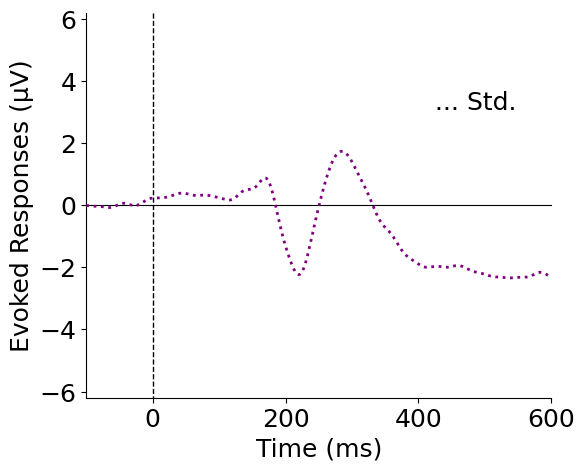

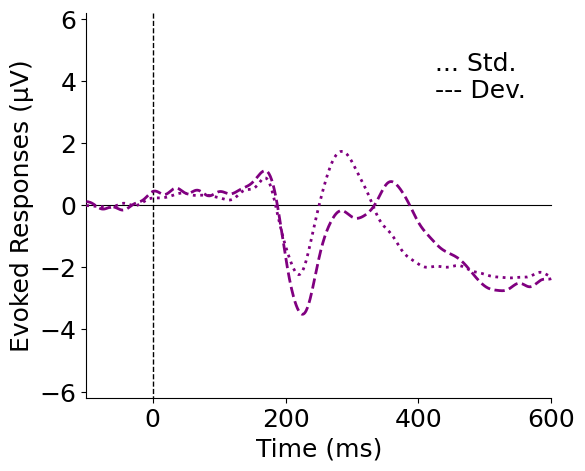

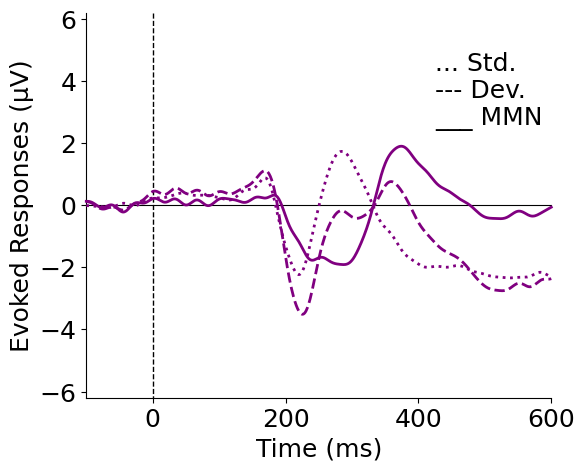

In [28]:
picks= ['F3', 'Cz', 'F4',]
# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.6
# End of time window
# ### Personalized siginificant ERP for all the categories
evokeds = {
    'Non PS std':B1_sta_combined_erp,
           
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Non Ps deviant': B2_devi_combined_erp,
           'Non PS std':B1_sta_combined_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Non Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Non Ps deviant': B2_devi_combined_erp,
           'Non PS std':B1_sta_combined_erp,
           'Non PS MMN': non_sign_MMN_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Non Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted'},
             'Non PS MMN' :  {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple','purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.71, f"___ MMN", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
plt.show( )# export it 

### Personal significNCE (smartphone notification )  MMN ERP

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_12176\1271207086.py:22: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_12176\1271207086.py:47: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_12176\1271207086.py:74: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green','green'],show_sensors=False,legend=False,


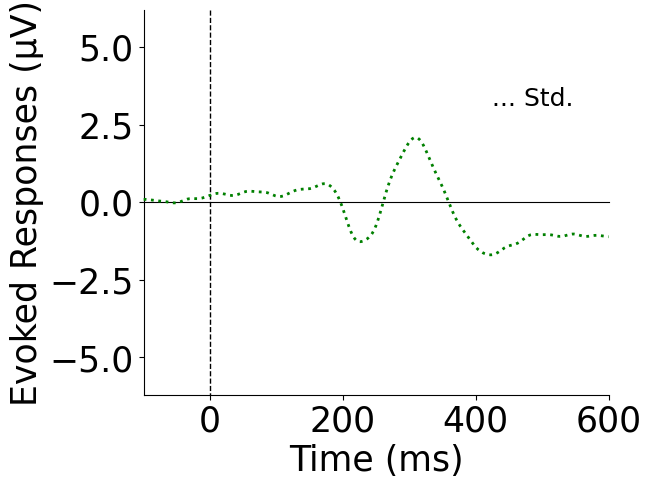

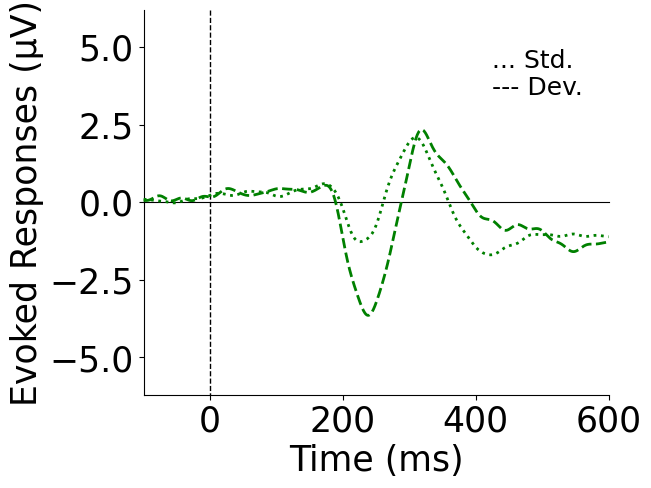

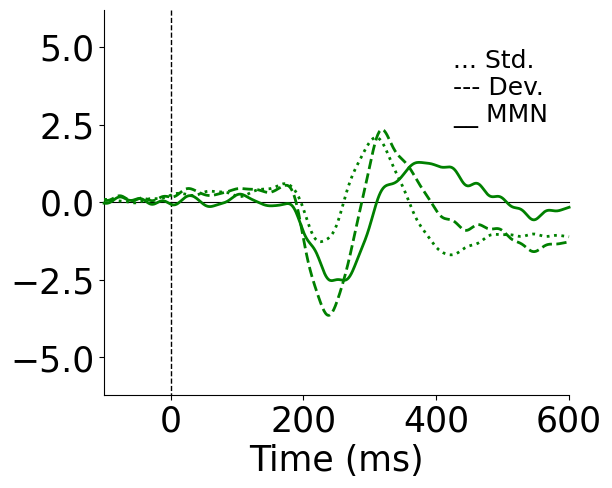

In [16]:
# ### Personalized siginificant ERP for all the categories
picks= ['F3', 'Cz', 'F4',]
evokeds = {
    'PS std':B2_sta_combined_erp,
           
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Ps deviant': B1_devi_combined_erp,
           'PS std':B2_sta_combined_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Ps deviant': B1_devi_combined_erp,
           'PS std':B2_sta_combined_erp,
           'PS MMN': Personal_MMN_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'PS std' : {"linewidth": 2,"linestyle":'dotted'},
             'PS MMN' :  {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green','green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.71, f"__ MMN", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
plt.show( )# export it 

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_12176\3767376524.py:21: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_12176\3767376524.py:46: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,


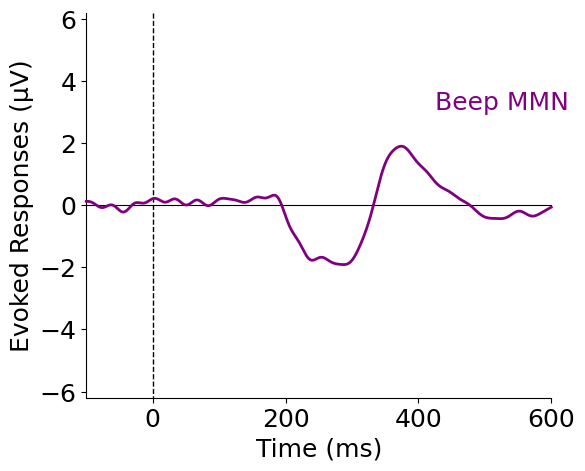

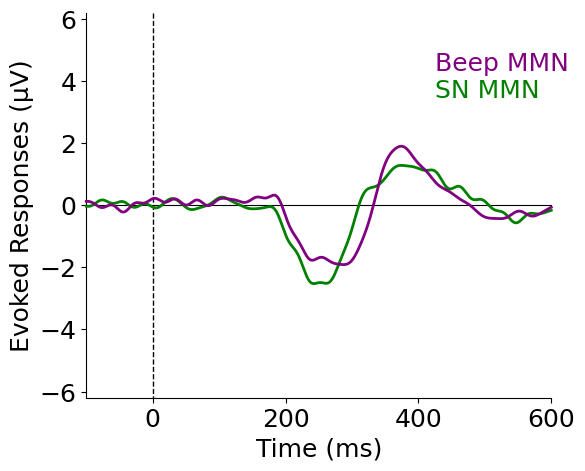

In [17]:

# ### Personalized siginificant ERP for all the categories
evokeds = {
    'NPS MMN':non_sign_MMN_erp,
           
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid',},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='purple')
axs.set_ylabel('Evoked Responses (µV)')
 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
    "PS MMN" : Personal_MMN_erp,
    'NPS MMN':non_sign_MMN_erp,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={"PS MMN": {"linewidth": 2,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.85, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='Purple')
axs.text( 0.75,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
# Plot the evoked responses

# Smartphone usage based group

In [18]:
subject_info= pd.read_excel(r"E:\ecf-exp2-notif-mmn\data\Processed\Participant_details.xlsx")
subject_info.head()

,SN,Subject Id,Age,Data collection location,Is controlled block?,gender,MPPUS score,SAS score,profession,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,1,sub002,31,IITJ,no,Male,60,50,PG_acd,NaN,NaN,NaN
1,2,sub003,29,IITJ,no,Female,176,130,PG_acd,NaN,NaN,NaN
2,3,sub004,21,IITJ,no,Male,124,107,UG_acd,NaN,NaN,NaN
3,4,sub005,26,IITJ,no,Male,140,104,PG_acd,NaN,NaN,NaN
4,5,sub006,25,IITJ,no,Male,107,60,PG_acd,NaN,NaN,NaN


In [19]:
subject_info["avg_S"] = subject_info[['MPPUS score',	'SAS score'	]].mean(axis=1)
subject_info_D=subject_info[subject_info["Subject Id"].str.contains("SD")]
subject_info_D

# Calculate 30th and 70th percentiles for SAS
sas_30 = subject_info_D['SAS score'].quantile(0.30) 
sas_70 = subject_info_D['SAS score'].quantile(0.60) 


# Calculate correlation coefficient
corr_coeff, _ = pearsonr(subject_info_D['MPPUS score'], subject_info_D['SAS score'])
# Create figure and axes

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, gridspec_kw={'width_ratios': [1, 1]},dpi =1000)  # Share y-axis for alignment
scatter_ax, hist_ax = axes

# === First subplot: Correlation Scatter Plot === #
# Color code based on SAS percentiles
colors = np.where(subject_info_D['SAS score'] >= sas_70, 'darkorange', 
                  np.where(subject_info_D['SAS score'] <= sas_30,'deepskyblue', 'black'))
colors = colors.tolist()
# Scatter plot
#scatter_ax.scatter(subject_info_D['MPPUS score'], subject_info_D['SAS score'], c=colors, alpha=0.8, edgecolor='k', s=70)
# Scatter plot with regression line (on the right subplot)
sns.regplot(x = subject_info_D['MPPUS score'], y= subject_info_D['SAS score'], ax=scatter_ax,
            scatter_kws={"color": colors, "s": 70, "edgecolor": "black"},line_kws=dict(color="grey",alpha=0.8,linewidth = 3)  )

scatter_ax.text(0.75, 0.65, f"r = {corr_coeff:.2f}", transform=scatter_ax.transAxes, fontsize=20, color='black')
scatter_ax.set_xlabel('MPPUS')
scatter_ax.set_ylabel('SAS')
scatter_ax.axhline(sas_30, color='deepskyblue', linestyle='solid',linewidth = 3, label='30th Percentile')
scatter_ax.axhline(sas_70, color='darkorange', linestyle='solid', linewidth = 3, label='70th Percentile')
# Add legend
scatter_ax.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=10, label='HSU Group'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='deepskyblue', markersize=10, label='LSU Group'),
    #plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Avg. Smartphone User Group'),
], loc='upper left',handletextpad=0.2)
# === Second subplot: SAS Histogram === #
hist_ax.hist(subject_info_D['SAS score'], bins=10, alpha=0.4,  color='grey',orientation='horizontal',edgecolor='black')

hist_ax.axhline(sas_30, color='deepskyblue', linestyle='solid',linewidth = 3, label='30th Percentile')
hist_ax.axhline(sas_70, color='darkorange', linestyle='solid', linewidth = 3, label='70th Percentile')

hist_ax.set_xlabel('Count')
hist_ax.legend()
# Remove space between plots
for s,spine in enumerate(axes[0].spines.values()):
    if s !=0 and s != 2 :
        print(s,spine)
        spine.set_visible(False)
# Remove space between plots
for s,spine in enumerate(axes[1].spines.values()):
    if s !=2 :
        print(s,spine)
        spine.set_visible(False)
plt.subplots_adjust(wspace=0.0)
# Adjust layout and show plot
plt.tight_layout()
plt.rcParams.update({
    'xtick.labelsize': 15,  # X-axis tick labels font size
    'ytick.labelsize': 15,  # Y-axis tick labels font size
    'axes.labelsize': 15,   # Axis label font size
    'axes.titlesize': 15,   # Title font size
    'legend.fontsize': 15,   # Legend font size
})
plt.show()


1 Spine
3 Spine
0 Spine
1 Spine
3 Spine


In [20]:
# low samrtphone user 
subject_info_D_low = subject_info_D[subject_info_D['SAS score']<=subject_info_D['SAS score'].quantile(.30)]
# high smartphone user 
subject_info_D_high = subject_info_D[subject_info_D['SAS score']>=subject_info_D['SAS score'].quantile(.70)]
# catogory subject list 
low_sub_D = list(subject_info_D_low['Subject Id'])

high_sub_D = list(subject_info_D_high['Subject Id'])


### LSU and HSU MMN

In [21]:
B1_devi_eps_evoked_list_low = [B1_devi_eps_evoked_dict[sub]  for sub in B1_devi_eps_evoked_dict if sub in low_sub_D]
B1_devi_combined_erp_low = mne.grand_average(B1_devi_eps_evoked_list_low)
 
B1_sta_eps_evoked_list_low = [B1_sta_eps_evoked_dict[sub]  for sub in B1_sta_eps_evoked_dict if sub in low_sub_D ]
B1_sta_combined_erp_low = mne.grand_average(B1_sta_eps_evoked_list_low ) 

B2_devi_eps_evoked_list_low = [B2_devi_eps_evoked_dict[sub]  for sub in B2_devi_eps_evoked_dict if sub in low_sub_D ]
B2_devi_combined_erp_low = mne.grand_average(B2_devi_eps_evoked_list_low)

B2_sta_eps_evoked_list_low = [B2_sta_eps_evoked_dict[sub]  for sub in B2_sta_eps_evoked_dict if sub in low_sub_D  ]
B2_sta_combined_erp_low = mne.grand_average(B2_sta_eps_evoked_list_low )     

Personal_MMN_erp_low = mne.combine_evoked([B1_devi_combined_erp_low ,B2_sta_combined_erp_low], weights=[1,-1])

non_sign_MMN_erp_low = mne.combine_evoked([B2_devi_combined_erp_low,B1_sta_combined_erp_low], weights=[1,-1])  


Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...


combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_12176\2291197033.py:20: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,


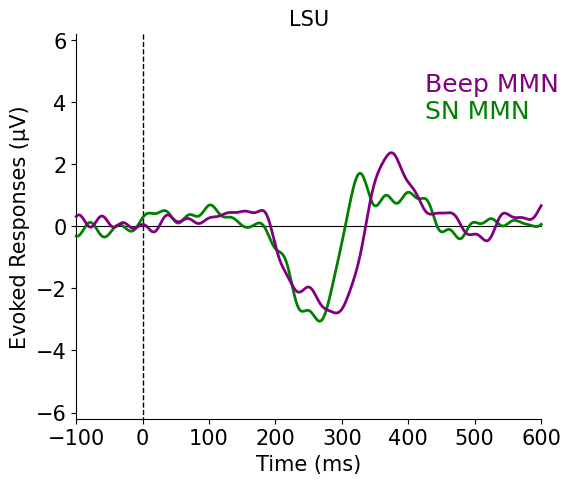

In [22]:
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
    "PS MMN" : Personal_MMN_erp_low,
    'NPS MMN':non_sign_MMN_erp_low,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={"PS MMN": {"linewidth": 2,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='LSU')
axs.text( 0.75,0.85, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='Purple')
axs.text( 0.75,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})

In [23]:
B1_devi_eps_evoked_list_high = [B1_devi_eps_evoked_dict[sub]  for sub in B1_devi_eps_evoked_dict if sub in high_sub_D]
B1_devi_combined_erp_high= mne.grand_average(B1_devi_eps_evoked_list_high)
 
B1_sta_eps_evoked_list_high = [B1_sta_eps_evoked_dict[sub]  for sub in B1_sta_eps_evoked_dict if sub in high_sub_D ]
B1_sta_combined_erp_high = mne.grand_average(B1_sta_eps_evoked_list_high ) 

B2_devi_eps_evoked_list_high = [B2_devi_eps_evoked_dict[sub]  for sub in B2_devi_eps_evoked_dict if sub in high_sub_D ]
B2_devi_combined_erp_high = mne.grand_average(B2_devi_eps_evoked_list_high)

B2_sta_eps_evoked_list_high = [B2_sta_eps_evoked_dict[sub]  for sub in B2_sta_eps_evoked_dict if sub in high_sub_D  ]
B2_sta_combined_erp_high = mne.grand_average(B2_sta_eps_evoked_list_high )     

Personal_MMN_erp_high = mne.combine_evoked([B1_devi_combined_erp_high ,B2_sta_combined_erp_high], weights=[1,-1])

non_sign_MMN_erp_high = mne.combine_evoked([B2_devi_combined_erp_high,B1_sta_combined_erp_high], weights=[1,-1])  

Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...


combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_12176\4080833218.py:20: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,


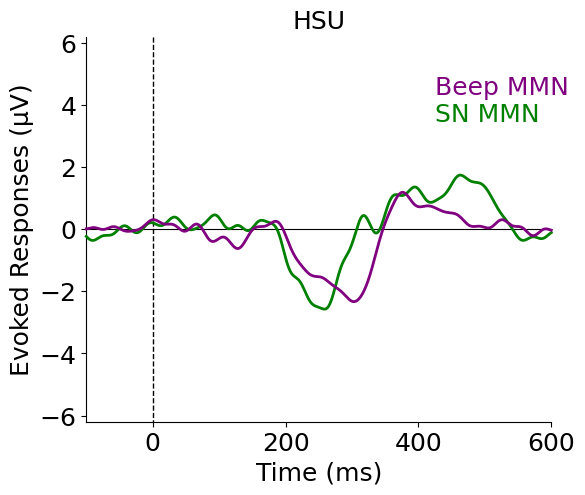

In [24]:
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
    "PS MMN" : Personal_MMN_erp_high,
    'NPS MMN':non_sign_MMN_erp_high,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={"PS MMN": {"linewidth": 2,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='HSU')
axs.text( 0.75,0.85, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='Purple')
axs.text( 0.75,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_12176\2383756477.py:20: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_12176\2383756477.py:40: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,


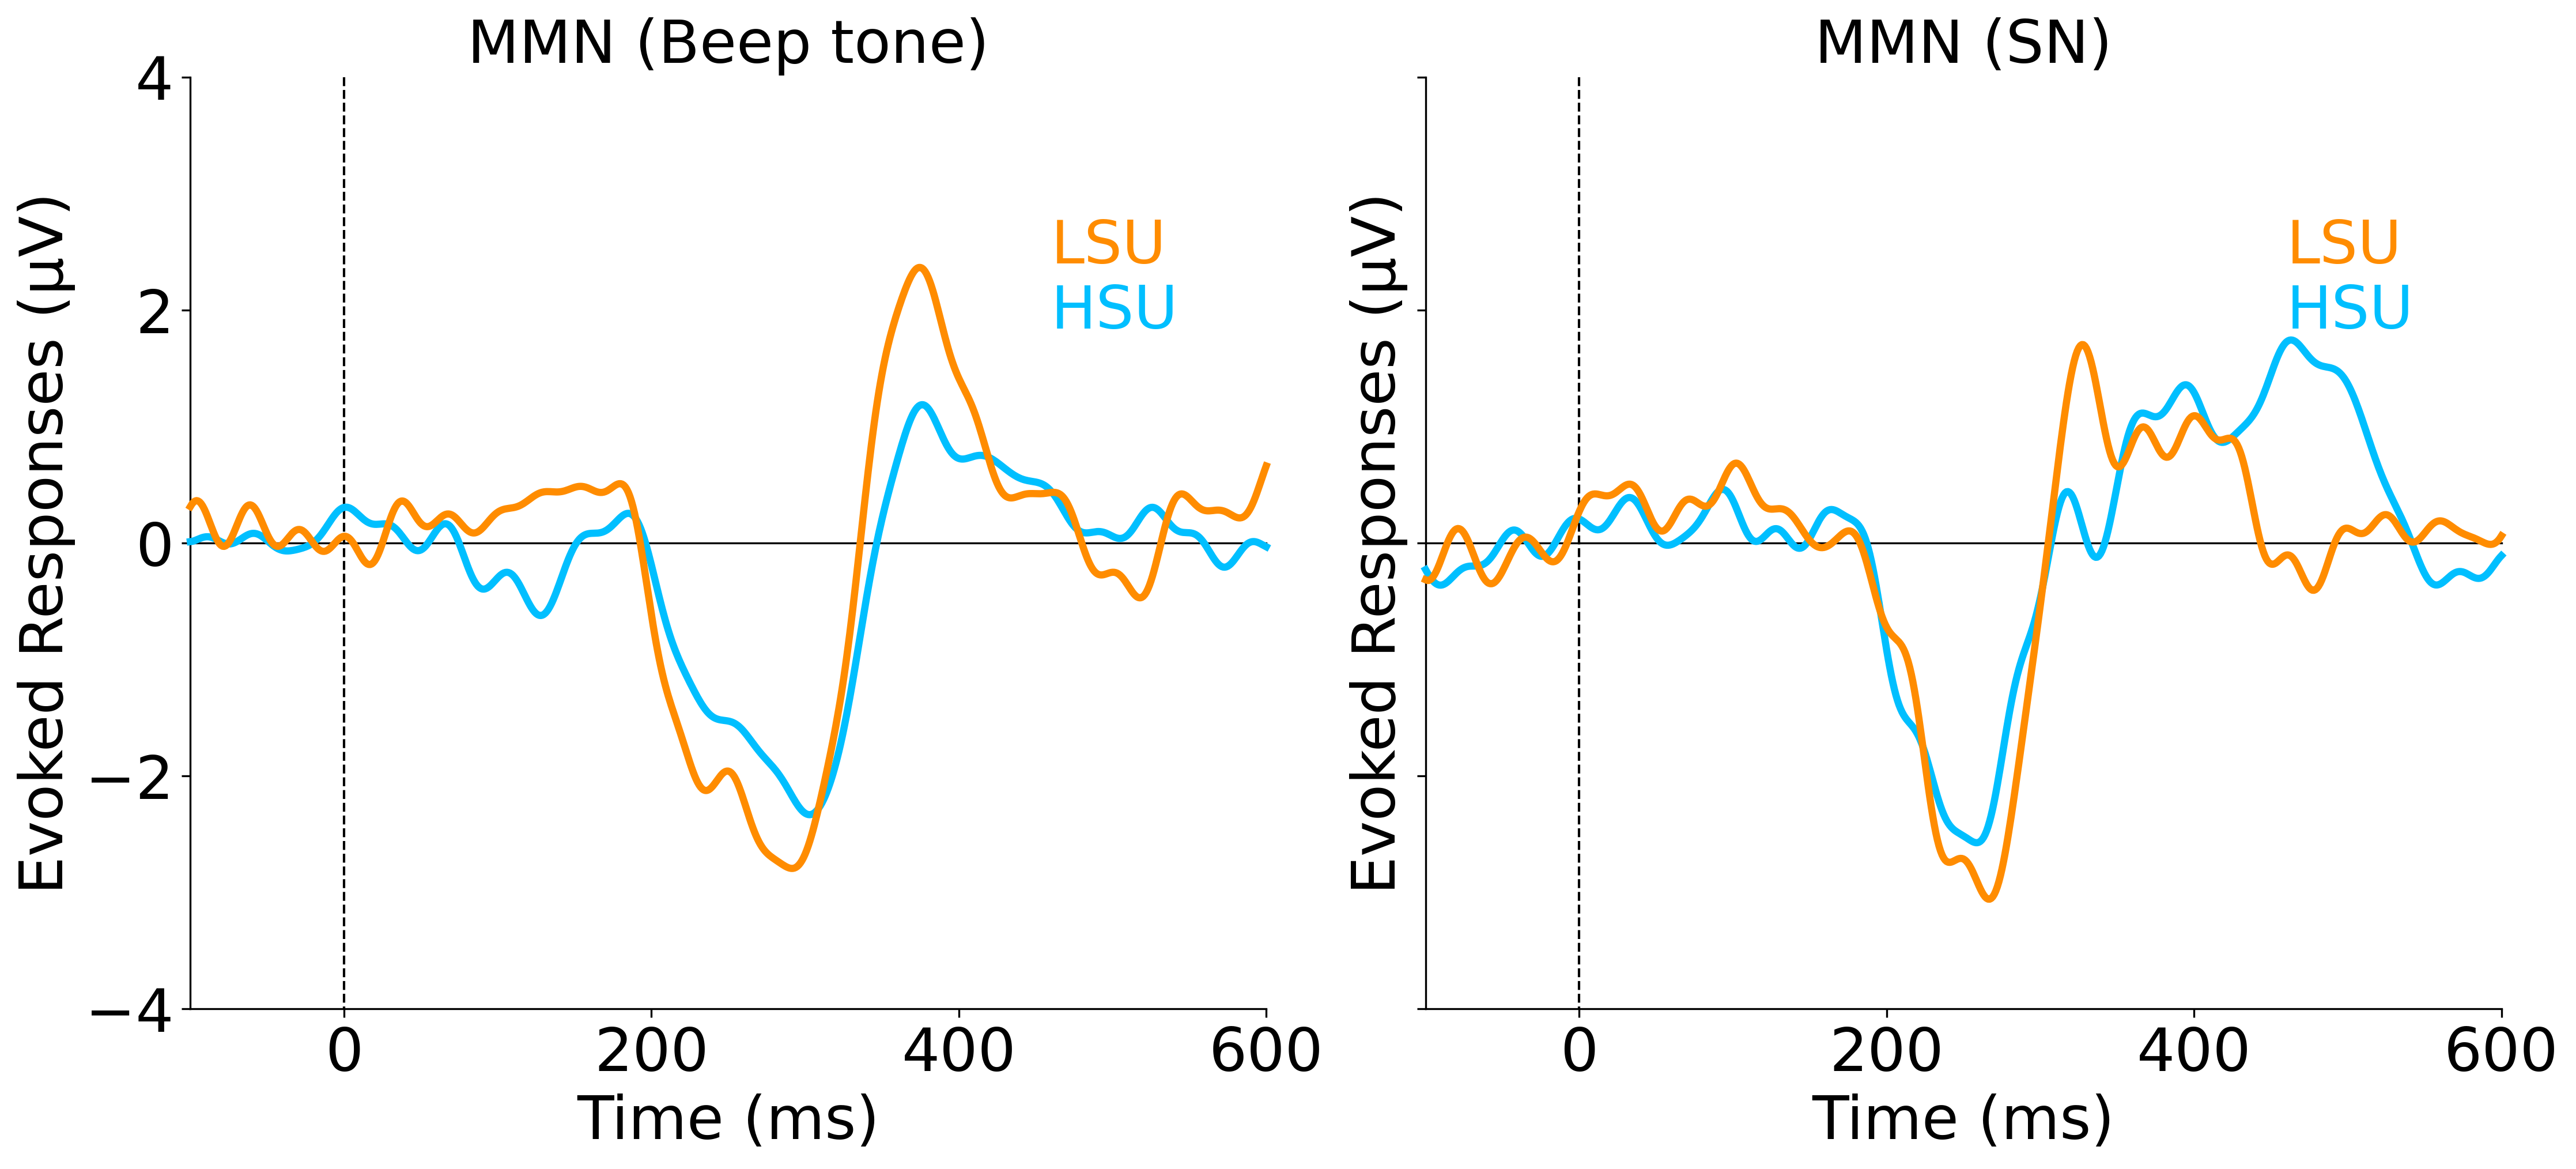

In [26]:
# ### Personalized siginificant ERP for all the categories
evokeds = {'HSU': Personal_MMN_erp_high,
           'LSU': Personal_MMN_erp_low,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1, 2, figsize=(15, 7),  sharey=True, gridspec_kw={'width_ratios': [1, 1]},dpi =300)

stylesdict ={'HSU': {"linewidth": 3,"linestyle":'solid'},
             'LSU' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-4,4]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='MMN (SN)')



# ### Non Personalized siginificant ERP for all the categories
evokeds = {'HSU': non_sign_MMN_erp_high,
           'LSU': non_sign_MMN_erp_low,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop


mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-4,4]),time_unit= 'ms',
                                   truncat e_xaxis=False,truncate_yaxis=False ,show= False,title='MMN (Beep tone)')


# Add an overall title for the whole plot
#fig.suptitle('Low, Medium and High smartphone user  ', fontsize=30)
axs[0].text(0.80,  0.73,f"HSU", transform=axs[0].transAxes, fontsize=25, color='deepskyblue')
axs[0].text( 0.80,0.80, f"LSU", transform=axs[0].transAxes, fontsize=25, color='darkorange')

axs[1].text(0.80,0.73, f"HSU", transform=axs[1].transAxes, fontsize=25, color='deepskyblue')
axs[1].text( 0.80,0.80, f"LSU", transform=axs[1].transAxes, fontsize=25, color='darkorange')
# Add an overall title for the whole plot

# Add an arrow pointing to a specific point
"""axs[0].text(0.50, 0.05, f"N1", transform=axs[0].transAxes, fontsize=24, color='black')
axs[0].text( 0.62,0.8, f"P1", transform=axs[0].transAxes, fontsize=24, color='black')
# Add an arrow pointing to a specific point
axs[1].text(0.45, 0.05, f"N1", transform=axs[1].transAxes, fontsize=24, color='black')

axs[1].text( 0.58,0.60, f"P1", transform=axs[1].transAxes, fontsize=24, color='black')

axs[1].text( 0.75,0.68, f"P2", transform=axs[1].transAxes, fontsize=24, color='black')"""
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.tight_layout(rect=[0, 0, 1, 0.98])
axes = fig.axes  # List of subplot axes
axes[0].set_ylabel('Evoked Responses (µV)')
axes[1].set_ylabel('Evoked Responses (µV)')
"""for ax in axes[1:]:  # Skip the first subplot (index 0)
    ax.set_ylabel('')"""
plt.rcParams.update({
    'xtick.labelsize': 25,  # X-axis tick labels font size
    'ytick.labelsize': 25,  # Y-axis tick labels font size
    'axes.labelsize': 25,   # Axis label font size
    'axes.titlesize': 25,   # Title font size 
    'legend.fontsize': 25,   # Legend font size
})
plt.show()